# Codon-conditioned backbone signal: robustness analysis

This notebook stress-tests the codon-pair rejections shown in Figure 1. For every pair
flagged significant by at least one two-sample statistic, it asks: how many of the most
influential observations would need to be removed before the rejection disappears
(adversarial breakdown-k), and does the same rejection survive under label-randomized
null controls that preserve every observation's (phi, psi)?

Everything below is derived live from the same `cc-pvals.csv` files Figure 1 loads --
re-running the upstream pipeline and then re-running this notebook regenerates every
number here with no manual step.

In [11]:
import sys
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

sys.path.insert(0, ".")
sys.path.insert(0, str(Path("../../scripts/pnas2026").resolve()))

from _pnas2026_common import LABELLED_TAGS, compute_bh_rejections, load_all_pvals
from _common import SEED

from pp5.dihedral import flat_torus_distance
from pp5.distributions.kde import gaussian_kernel
from pp5.stats.breakdown import breakdown_k_kde, breakdown_k_mmd
from pp5.stats.controls import (
    gen_aa_ss_control_replicates,
    gen_pooled_shuffle_replicates,
    null_control_summary,
)

FDR = 0.05
K_PERM = (
    5000  # permutations for real-pair baseline p-values and breakdown-k checkpoints
)
K_CTRL = 2000  # permutations for control-replicate baseline/breakdown checkpoints
N_CONTROL_REPLICATES = 30

# torus-W2 breakdown-k uses a separate, R-backed algorithm and is slow (the last full
# run over 6 pairs took ~50 minutes). Set True to recompute it live; when False, values
# are loaded from TORUS_CACHE_PATH, with graceful "not computed" handling for any
# candidate pair missing from that file.
RUN_TORUS_BREAKDOWN_LIVE = False
TORUS_CACHE_PATH = Path(
    "../../out/pnas-2026-phase1-golden/robustness_torus_summary.csv"
).resolve()

# The 5 statistics with an adversarial breakdown-k procedure.
BREAKDOWN_ARMS = [
    "kde-l1(bw=10.0)",
    "kde-l1(bw=CV)",
    "mmd(unbiased)",
    # "mmd(biased)",
    "w2torus(4-fixed)",
]
FAST_ARMS = [arm for arm in BREAKDOWN_ARMS if arm != "w2torus(4-fixed)"]

# Every CSV this notebook writes (one per breakdown-k arm, the joined table, and the
# kill-set/provenance table) lands here, keyed by name -- re-running the notebook
# regenerates them all with no manual step.
OUT_DIR = Path("../../out/pnas2026/robustness").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load p-values

Same registry and loader Figure 1 uses (`_pnas2026_common.py`), so this notebook can never
diverge on which runs or thresholds are in play.

In [12]:
df_all_pvals = load_all_pvals(LABELLED_TAGS)
df_rejections = compute_bh_rejections(df_all_pvals, fdr=FDR)
real_rejections = df_rejections[
    (df_rejections["codon_randomization"] == "none")
    & (df_rejections["stat_test"].isin(BREAKDOWN_ARMS))
].reset_index(drop=True)
real_rejections

,stat_test,codon_randomization,SS,n_hypotheses,fdr,bh_pvalue_threshold,n_rejected,rejected_pairs
0,w2torus(4-fixed),none,HELIX,87,0.05,0.002299,4,"[L-CTC:L-TTG, L-CTC:L-CTG, L-CTC:L-CTT, R-AGG:..."
1,w2torus(4-fixed),none,OTHER,87,0.05,0.000000,0,[]
2,w2torus(4-fixed),none,SHEET,87,0.05,0.000000,0,[]
3,w2torus(4-fixed),none,TURN,87,0.05,0.000575,1,[A-GCG:A-GCT]
4,kde-l1(bw=10.0),none,HELIX,87,0.05,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
5,kde-l1(bw=10.0),none,OTHER,87,0.05,0.000000,0,[]
6,kde-l1(bw=10.0),none,SHEET,87,0.05,0.000000,0,[]
7,kde-l1(bw=10.0),none,TURN,87,0.05,0.001149,2,"[P-CCC:P-CCG, A-GCG:A-GCT]"
8,kde-l1(bw=CV),none,HELIX,87,0.05,0.000575,1,[L-CTC:L-TTG]
9,kde-l1(bw=CV),none,OTHER,87,0.05,0.000000,0,[]


## Load raw inputs

The pvals CSVs only carry aggregated statistics per codon pair; the breakdown-k and
provenance analysis below needs the underlying per-position data: the aggregated
dataset, the cross-validated KDE bandwidths (for the KDE-CV arm), and the raw
per-structure records (for PDB provenance).

In [13]:
DATASET_PATH = Path(
    "../../out/prec-collected/20211001_124553-aida-ex_EC-src_EC/results/"
    "pointwise_cdist-natcom/_intermediate_/dataset.csv"
).resolve()
CV_BANDWIDTH_PATH = Path(
    "../../out/pnas-2026/bandwidth_cv/kernel_bandwidths.csv"
).resolve()
PROVENANCE_PATH = Path(
    "../../out/prec-collected/20211001_124553-aida-ex_EC-src_EC/data-precs.csv"
).resolve()

assert DATASET_PATH.is_file(), DATASET_PATH
assert CV_BANDWIDTH_PATH.is_file(), CV_BANDWIDTH_PATH
assert PROVENANCE_PATH.is_file(), PROVENANCE_PATH

df_dataset = pd.read_csv(DATASET_PATH)
if "AA" not in df_dataset.columns:
    df_dataset["AA"] = df_dataset["codon"].str.split("-").str[0]

df_cv_bandwidth = pd.read_csv(CV_BANDWIDTH_PATH).set_index(["codon", "ss"])[
    "sigma_cv_deg"
]

## Determine candidate pairs

A pair is a candidate for breakdown-k if at least one of the 5 statistics above rejects
it in the real data, at that statistic's own BH threshold. This replaces any fixed pair
list: a future rerun with different p-values changes the candidate set automatically.

In [14]:
candidate_pairs = sorted(
    {
        (row.SS, pair)
        for row in real_rejections.itertuples()
        for pair in row.rejected_pairs
    }
)
print(f"{len(candidate_pairs)} candidate pairs:")
for ss, pair in candidate_pairs:
    print(f"  {ss}  {pair}")

# Sanity check against the historical stress-test set documented in the revision plan
# (Section 4): the same union should still appear, since these pvals are the ones that
# set produced.
HISTORICAL_UNION = {
    ("HELIX", "L-CTC:L-TTG"),
    ("HELIX", "L-CTC:L-CTG"),
    ("HELIX", "L-CTC:L-CTT"),
    ("HELIX", "R-AGG:R-CGA"),
    ("TURN", "A-GCG:A-GCT"),
    ("TURN", "P-CCC:P-CCG"),
}
missing = HISTORICAL_UNION - set(candidate_pairs)
assert not missing, (
    f"Historical stress-test pairs missing from the candidate set: {missing}"
)

6 candidate pairs:
  HELIX  L-CTC:L-CTG
  HELIX  L-CTC:L-CTT
  HELIX  L-CTC:L-TTG
  HELIX  R-AGG:R-CGA
  TURN  A-GCG:A-GCT
  TURN  P-CCC:P-CCG


## Shared helpers

`codon_angles` extracts one codon's (phi, psi) points (in radians) for a secondary-structure
class, plus the (unp_id, unp_idx) key of each point (needed later to trace adversarially-removed
points back to PDB structures). `k_grid_for` is the adversarial-removal checkpoint schedule,
used identically by every arm below.

In [15]:
def codon_angles(
    df: pd.DataFrame, ss: str, codon: str
) -> tuple[np.ndarray, np.ndarray]:
    """Radian (phi, psi) points and (unp_id, unp_idx) keys for one (SS, codon) group.

    :param df: Dataset with columns `condition_group`, `codon`, `phi`, `psi`, `unp_id`,
        `unp_idx`.
    :param ss: Secondary-structure class, e.g. `"HELIX"`.
    :param codon: Codon label, e.g. `"L-CTC"`.
    :return: `(n, 2)` radian phi/psi array, `(n, 2)` object array of (unp_id, unp_idx).
    """
    sub = df[(df["condition_group"] == ss) & (df["codon"] == codon)]
    points = np.deg2rad(sub[["phi", "psi"]].to_numpy())
    keys = sub[["unp_id", "unp_idx"]].to_numpy()
    return points, keys


def k_grid_for(n_min: int) -> list[int]:
    """Adaptive breakdown-k checkpoint grid, capped so the smaller group keeps >= 2 points.

    :param n_min: Size of the smaller of the two groups being compared.
    :return: Sorted list of checkpoint values, each `<= n_min - 2`.
    """
    k_cap = min(40, max(5, int(np.ceil(0.05 * n_min))))
    grid = sorted({0, 1, 2, 3, 5, 8, 12, 20, k_cap})
    return [k for k in grid if k <= n_min - 2]

## Breakdown-k per statistic

For each candidate pair, under each of the 4 fast statistics (KDE-fix, KDE-CV, MMD-unbiased,
MMD-biased), compute the baseline p-value; if it clears that statistic's own BH threshold,
run the adversarial breakdown-k procedure (greedily remove the most influential remaining
observation, re-ranked each time, until the pair is no longer significant) and the same
statistic's AA+SS and pooled-shuffle null controls. Non-significant (pair, statistic)
combinations are recorded with `breakdown_k=None` and no controls, matching how they'd be
reported as "n.s." in the summary table later.

Each arm runs in its own cell below (via the shared `compute_breakdown_for_arm` helper), with
a progress bar over `candidate_pairs` and its own CSV written to `OUT_DIR` on completion --
this keeps a slow arm (MMD in particular) independently re-runnable without re-running the
others, and gives visibility into progress instead of a single silent multi-minute cell.

In [16]:
def baseline_pval(breakdown_fn, X: np.ndarray, Y: np.ndarray) -> tuple[float, float]:
    """Baseline (ddist, p) at k=0, via the same breakdown_fn used for the real computation.

    :param breakdown_fn: A `(X, Y, thresh, k_grid) -> (rows, breakdown_k, removed_log)`
        callable, e.g. as built by `build_kde_fix_breakdown_fn`.
    :param X: `(n1, 2)` radian phi/psi observations for group 1.
    :param Y: `(n2, 2)` radian phi/psi observations for group 2.
    :return: (ddist, p) at the full, unmodified sample.
    """
    # thresh=1.0 + k_grid=[0] guarantees the loop stops after computing exactly the
    # k=0 checkpoint, without ever attempting a removal.
    rows, _, _ = breakdown_fn(X, Y, thresh=1.0, k_grid=[0])
    return rows[0]["ddist"], rows[0]["p"]


# Shared accumulators, appended to by this task and Task 7 (torus arm).
breakdown_rows: list[dict] = []
p_trajectories: dict[tuple[str, str, str], list[dict]] = {}
removed_logs: dict[tuple[str, str, str], dict] = {}

In [17]:
NBINS, GRID_LOW, GRID_HIGH, DTYPE = 128, -np.pi, np.pi, np.float64
SIGMA_FIXED_RAD = np.deg2rad(10.0)


def build_kde_fix_breakdown_fn(sigma_rad: float, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the fixed-bandwidth KDE-L1 arm.

    :param sigma_rad: Shared bandwidth (radians) for both groups.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates (control
        replicates don't need the same permutation count as the real pair, and
        using the smaller `K_CTRL` keeps the 60-replicates-per-arm control cost
        tractable).
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_kde(
            X,
            Y,
            n_bins=NBINS,
            grid_low=GRID_LOW,
            grid_high=GRID_HIGH,
            dtype=DTYPE,
            sigma_x_rad=sigma_rad,
            sigma_y_rad=sigma_rad,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def build_kde_cv_breakdown_fn(sigma_x_rad: float, sigma_y_rad: float, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the per-codon CV-bandwidth KDE-L1 arm.

    :param sigma_x_rad: Group-1 (codon 1) bandwidth, radians.
    :param sigma_y_rad: Group-2 (codon 2) bandwidth, radians.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates.
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_kde(
            X,
            Y,
            n_bins=NBINS,
            grid_low=GRID_LOW,
            grid_high=GRID_HIGH,
            dtype=DTYPE,
            sigma_x_rad=sigma_x_rad,
            sigma_y_rad=sigma_y_rad,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def build_mmd_breakdown_fn(unbiased: bool, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the MMD^2 arm.

    :param unbiased: If True, use the unbiased U-statistic; if False, the biased
        V-statistic.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates. MMD's
        breakdown-k rebuilds the full Gram matrix at every removal step (no
        shared precomputed representation, unlike the KDE arms), so this
        matters most here: at `K_PERM` every one of the 60 control replicates
        per (pair, arm) would re-run a full-cost permutation test, which is
        what makes `K_CTRL` (2000, vs. 5000) worth having as a distinct value.
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_mmd(
            X,
            Y,
            similarity_fn=flat_torus_distance,
            kernel_fn=partial(gaussian_kernel, sigma=SIGMA_FIXED_RAD),
            unbiased=unbiased,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def breakdown_fn_for_arm(arm: str, ss: str, codon1: str, codon2: str, k_perm: int):
    """Look up the `(X, Y, thresh, k_grid) -> ...` breakdown_fn for one of the 4 fast arms.

    The single entry point every fast arm goes through, so the compute loop below
    doesn't need one branch per arm family.

    :param arm: One of `FAST_ARMS`.
    :param ss: Secondary-structure class (needed to look up the CV bandwidth).
    :param codon1: First codon label (needed to look up the CV bandwidth).
    :param codon2: Second codon label (needed to look up the CV bandwidth).
    :param k_perm: Number of permutations to use -- pass `K_PERM` for the real
        pair, `K_CTRL` when building the breakdown_fn used for control replicates.
    :return: The breakdown_fn for this arm, specialized to this pair where relevant.
    """
    if arm == "kde-l1(bw=10.0)":
        return build_kde_fix_breakdown_fn(SIGMA_FIXED_RAD, k_perm=k_perm)
    if arm == "kde-l1(bw=CV)":
        sigma_x = np.deg2rad(float(df_cv_bandwidth.loc[(codon1, ss)]))
        sigma_y = np.deg2rad(float(df_cv_bandwidth.loc[(codon2, ss)]))
        return build_kde_cv_breakdown_fn(sigma_x, sigma_y, k_perm=k_perm)
    if arm == "mmd(unbiased)":
        return build_mmd_breakdown_fn(unbiased=True, k_perm=k_perm)
    if arm == "mmd(biased)":
        return build_mmd_breakdown_fn(unbiased=False, k_perm=k_perm)
    raise ValueError(
        f"No fast breakdown_fn for arm {arm!r} (torus is handled separately)"
    )

In [18]:
def compute_breakdown_for_pair(arm: str, ss: str, pair: str, k_perm: int) -> dict:
    """Baseline p-value, breakdown-k, and null-control summary for one (pair, arm).

    Records the p(k) trajectory and adversarial-removal log for this (ss, pair, arm)
    into the shared `p_trajectories`/`removed_logs` dicts when the pair is significant
    (used later by the kill-set lookup and the R1 trajectory plots).

    :param arm: One of `FAST_ARMS`.
    :param ss: Secondary-structure class, e.g. `"HELIX"`.
    :param pair: `"<codon1>:<codon2>"` label, e.g. `"L-CTC:L-TTG"`.
    :param k_perm: Permutations for the real pair's baseline p-value and breakdown-k
        checkpoints (`K_PERM`); control replicates always use `K_CTRL` internally.
    :return: One row, matching the columns written to `breakdown_rows` elsewhere.
    """
    codon1, codon2 = pair.split(":")
    X, keys1 = codon_angles(df_dataset, ss, codon1)
    Y, keys2 = codon_angles(df_dataset, ss, codon2)
    n1, n2 = len(X), len(Y)
    k_grid = k_grid_for(min(n1, n2))

    breakdown_fn = breakdown_fn_for_arm(arm, ss, codon1, codon2, k_perm=k_perm)

    arm_row = real_rejections[
        (real_rejections["stat_test"] == arm) & (real_rejections["SS"] == ss)
    ]
    assert len(arm_row) == 1, f"Expected exactly one threshold row for {(arm, ss)}"
    thresh = float(arm_row["bh_pvalue_threshold"].iloc[0])

    ddist0, p0 = baseline_pval(breakdown_fn, X, Y)
    significant = p0 <= thresh

    row = dict(
        SS=ss,
        pair=pair,
        statistic=arm,
        n1=n1,
        n2=n2,
        ddist=ddist0,
        p=p0,
        significant=significant,
        breakdown_k=None,
        breakdown_pct=None,
        aass_frac_sig=None,
        aass_bk_median=None,
        aass_bk_max=None,
        aass_min_p0=None,
        pooled_frac_sig=None,
        pooled_bk_median=None,
        pooled_bk_max=None,
        pooled_min_p0=None,
        # Kept alongside the torus arm's own `source` values ("computed live" /
        # "cached (...)" / "not computed -- ...") so every arm's rows share the same
        # column set -- otherwise concatenating frames with a torus-only column
        # leaves it all-NaN for these rows, which pandas treats as an all-NA column
        # for dtype-inference purposes (a real FutureWarning, not just noise).
        source="computed",
    )

    if significant:
        rows, breakdown_k, removed_log = breakdown_fn(X, Y, thresh, k_grid)
        p_trajectories[(ss, pair, arm)] = rows
        removed_logs[(ss, pair, arm)] = dict(
            removed_log=removed_log,
            keys1=keys1,
            keys2=keys2,
            codon1=codon1,
            codon2=codon2,
        )

        # Controls get their own breakdown_fn built at K_CTRL (2000), not K_PERM
        # (5000): 60 replicates/arm at the real pair's permutation count would
        # be far more expensive than the real computation itself, especially
        # for MMD, which rebuilds its Gram matrix from scratch at every step.
        # Default-arg `fn=control_breakdown_fn` captures *this* call's closure
        # value; without it, a shared lambda across calls would see whichever
        # breakdown_fn happened to be built last, not the one for this arm.
        control_breakdown_fn = breakdown_fn_for_arm(
            arm, ss, codon1, codon2, k_perm=K_CTRL
        )
        aa_ss_ctrl = null_control_summary(
            gen_aa_ss_control_replicates(
                df_dataset, ss, codon1, codon2, N_CONTROL_REPLICATES, SEED
            ),
            pval_fn=lambda X_, Y_, fn=control_breakdown_fn: baseline_pval(fn, X_, Y_),
            breakdown_fn=control_breakdown_fn,
            thresh=thresh,
            k_grid_fn=k_grid_for,
        )
        pooled_ctrl = null_control_summary(
            gen_pooled_shuffle_replicates(X, Y, N_CONTROL_REPLICATES, SEED + 13),
            pval_fn=lambda X_, Y_, fn=control_breakdown_fn: baseline_pval(fn, X_, Y_),
            breakdown_fn=control_breakdown_fn,
            thresh=thresh,
            k_grid_fn=k_grid_for,
        )

        row.update(
            breakdown_k=breakdown_k,
            breakdown_pct=(breakdown_k / min(n1, n2) * 100) if breakdown_k else None,
            aass_frac_sig=aa_ss_ctrl["frac_sig"],
            aass_bk_median=aa_ss_ctrl["bk_median"],
            aass_bk_max=aa_ss_ctrl["bk_max"],
            aass_min_p0=aa_ss_ctrl["min_p0"],
            pooled_frac_sig=pooled_ctrl["frac_sig"],
            pooled_bk_median=pooled_ctrl["bk_median"],
            pooled_bk_max=pooled_ctrl["bk_max"],
            pooled_min_p0=pooled_ctrl["min_p0"],
        )

    return row


def compute_breakdown_for_arm(arm: str, k_perm: int = K_PERM) -> pd.DataFrame:
    """Run `compute_breakdown_for_pair` over every candidate pair for one arm.

    Shows a progress bar over `candidate_pairs`, since a single arm can take several
    minutes (MMD in particular rebuilds its Gram matrix from scratch at every
    adversarial-removal step).

    :param arm: One of `FAST_ARMS`.
    :param k_perm: Permutations for the real pair's baseline p-value and breakdown-k
        checkpoints.
    :return: One row per candidate pair, same columns as `compute_breakdown_for_pair`.
    """
    rows = [
        compute_breakdown_for_pair(arm, ss, pair, k_perm=k_perm)
        for ss, pair in tqdm(candidate_pairs, desc=arm)
    ]
    return pd.DataFrame(rows)

#### KDE-fix arm (sigma=10 deg, fixed bandwidth)

In [19]:
ARM = "kde-l1(bw=10.0)"
if ARM in FAST_ARMS:
    df_kde_fix = compute_breakdown_for_arm(ARM)
    breakdown_rows.extend(df_kde_fix.to_dict("records"))
    df_kde_fix.to_csv(OUT_DIR / "breakdown_kde_fix.csv", index=False)
else:
    df_kde_fix = pd.DataFrame()
    print(f"{ARM!r} not in FAST_ARMS -- skipping (no CSV written)")
df_kde_fix

kde-l1(bw=10.0):   0%|          | 0/6 [00:00<?, ?it/s]

,SS,pair,statistic,n1,n2,ddist,p,significant,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),528,2812,0.096589,0.000800,True,1.0,0.189394,0.0,0.0,0.0,0.026987,0.0,0.0,0.0,0.012994,computed
1,HELIX,L-CTC:L-CTT,kde-l1(bw=10.0),528,530,0.085733,0.053989,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),528,599,0.125916,0.000600,True,8.0,1.515152,0.0,0.0,0.0,0.017491,0.0,0.0,0.0,0.071464,computed
3,HELIX,R-AGG:R-CGA,kde-l1(bw=10.0),63,140,0.168580,0.143771,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,kde-l1(bw=10.0),350,203,0.399174,0.000200,True,8.0,3.940887,0.0,0.0,0.0,0.030485,0.0,0.0,0.0,0.029985,computed
5,TURN,P-CCC:P-CCG,kde-l1(bw=10.0),132,500,0.399185,0.000200,True,8.0,6.060606,0.0,0.0,0.0,0.090455,0.0,0.0,0.0,0.008496,computed


#### KDE-CV arm (per-codon cross-validated bandwidth)

In [20]:
ARM = "kde-l1(bw=CV)"
if ARM in FAST_ARMS:
    df_kde_cv = compute_breakdown_for_arm(ARM)
    breakdown_rows.extend(df_kde_cv.to_dict("records"))
    df_kde_cv.to_csv(OUT_DIR / "breakdown_kde_cv.csv", index=False)
else:
    df_kde_cv = pd.DataFrame()
    print(f"{ARM!r} not in FAST_ARMS -- skipping (no CSV written)")
df_kde_cv

kde-l1(bw=CV):   0%|          | 0/6 [00:00<?, ?it/s]

,SS,pair,statistic,n1,n2,ddist,p,significant,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,kde-l1(bw=CV),528,2812,0.378161,0.399520,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
1,HELIX,L-CTC:L-CTT,kde-l1(bw=CV),528,530,0.288744,0.039792,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,kde-l1(bw=CV),528,599,0.305241,0.001000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
3,HELIX,R-AGG:R-CGA,kde-l1(bw=CV),63,140,0.447527,0.003799,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,kde-l1(bw=CV),350,203,0.625578,0.000200,True,2.0,0.985222,0.0,0.0,0.0,0.021489,0.0,0.0,0.0,0.043478,computed
5,TURN,P-CCC:P-CCG,kde-l1(bw=CV),132,500,0.624265,0.054389,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed


#### MMD arm (unbiased U-statistic)

In [21]:
ARM = "mmd(unbiased)"
if ARM in FAST_ARMS:
    df_mmd_unbiased = compute_breakdown_for_arm(ARM)
    breakdown_rows.extend(df_mmd_unbiased.to_dict("records"))
    df_mmd_unbiased.to_csv(OUT_DIR / "breakdown_mmd_unbiased.csv", index=False)
else:
    df_mmd_unbiased = pd.DataFrame()
    print(f"{ARM!r} not in FAST_ARMS -- skipping (no CSV written)")
df_mmd_unbiased

mmd(unbiased):   0%|          | 0/6 [00:00<?, ?it/s]

,SS,pair,statistic,n1,n2,ddist,p,significant,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,mmd(unbiased),528,2812,0.003353,0.002000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
1,HELIX,L-CTC:L-CTT,mmd(unbiased),528,530,0.002146,0.042392,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,mmd(unbiased),528,599,0.006413,0.000800,True,5.0,0.946970,0.0,0.0,0.0,0.024488,0.0,0.0,0.0,0.012994,computed
3,HELIX,R-AGG:R-CGA,mmd(unbiased),63,140,0.014490,0.029394,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,mmd(unbiased),350,203,0.024055,0.000200,True,8.0,3.940887,0.0,0.0,0.0,0.029985,0.0,0.0,0.0,0.031484,computed
5,TURN,P-CCC:P-CCG,mmd(unbiased),132,500,0.026446,0.001000,True,3.0,2.272727,0.0,0.0,0.0,0.122939,0.0,0.0,0.0,0.010995,computed


#### MMD arm (biased V-statistic)

In [22]:
ARM = "mmd(biased)"
if ARM in FAST_ARMS:
    df_mmd_biased = compute_breakdown_for_arm(ARM)
    breakdown_rows.extend(df_mmd_biased.to_dict("records"))
    df_mmd_biased.to_csv(OUT_DIR / "breakdown_mmd_biased.csv", index=False)
else:
    df_mmd_biased = pd.DataFrame()
    print(f"{ARM!r} not in FAST_ARMS -- skipping (no CSV written)")
df_mmd_biased

'mmd(biased)' not in FAST_ARMS -- skipping (no CSV written)


""


### torus-W2 arm (flagged: live or cached)

torus-W2's breakdown-k uses a different, R-backed algorithm (recomputing the analytic
projected-Wasserstein test at each removal checkpoint via the vendored `torustest`), and it
is slow: the last full run over 6 pairs took roughly 50 minutes. Set `RUN_TORUS_BREAKDOWN_LIVE
= True` above to recompute it here; otherwise this section loads breakdown-k from
`TORUS_CACHE_PATH`, and any candidate pair not present in that file is recorded as
"not computed" rather than causing an error.

In [23]:
torus_rows = []

if RUN_TORUS_BREAKDOWN_LIVE:
    sys.path.insert(0, str(Path("../../scripts/pnas2026").resolve()))
    from robustness_torus import breakdown_torus, torus_pval

    for ss, pair in tqdm(candidate_pairs, desc="w2torus(4-fixed)"):
        codon1, codon2 = pair.split(":")
        X, keys1 = codon_angles(df_dataset, ss, codon1)
        Y, keys2 = codon_angles(df_dataset, ss, codon2)
        n1, n2 = len(X), len(Y)
        k_grid = k_grid_for(min(n1, n2))

        arm_row = real_rejections[
            (real_rejections["stat_test"] == "w2torus(4-fixed)")
            & (real_rejections["SS"] == ss)
        ]
        assert len(arm_row) == 1
        thresh = float(arm_row["bh_pvalue_threshold"].iloc[0])

        stat0, p0 = torus_pval(X, Y)
        significant = p0 <= thresh

        row = dict(
            SS=ss,
            pair=pair,
            statistic="w2torus(4-fixed)",
            n1=n1,
            n2=n2,
            ddist=stat0,
            p=p0,
            significant=significant,
            breakdown_k=None,
            breakdown_pct=None,
            aass_frac_sig=None,
            aass_bk_median=None,
            aass_bk_max=None,
            aass_min_p0=None,
            pooled_frac_sig=None,
            pooled_bk_median=None,
            pooled_bk_max=None,
            pooled_min_p0=None,
            source="computed live",
        )

        if significant:
            rows, breakdown_k, removed_log = breakdown_torus(X, Y, thresh, k_grid)
            p_trajectories[(ss, pair, "w2torus(4-fixed)")] = rows
            removed_logs[(ss, pair, "w2torus(4-fixed)")] = dict(
                removed_log=removed_log,
                keys1=keys1,
                keys2=keys2,
                codon1=codon1,
                codon2=codon2,
            )

            aa_ss_ctrl = null_control_summary(
                gen_aa_ss_control_replicates(
                    df_dataset, ss, codon1, codon2, N_CONTROL_REPLICATES, SEED
                ),
                pval_fn=torus_pval,
                breakdown_fn=breakdown_torus,
                thresh=thresh,
                k_grid_fn=k_grid_for,
            )
            pooled_ctrl = null_control_summary(
                gen_pooled_shuffle_replicates(X, Y, N_CONTROL_REPLICATES, SEED + 13),
                pval_fn=torus_pval,
                breakdown_fn=breakdown_torus,
                thresh=thresh,
                k_grid_fn=k_grid_for,
            )

            row.update(
                breakdown_k=breakdown_k,
                breakdown_pct=(breakdown_k / min(n1, n2) * 100)
                if breakdown_k
                else None,
                aass_frac_sig=aa_ss_ctrl["frac_sig"],
                aass_bk_median=aa_ss_ctrl["bk_median"],
                aass_bk_max=aa_ss_ctrl["bk_max"],
                aass_min_p0=aa_ss_ctrl["min_p0"],
                pooled_frac_sig=pooled_ctrl["frac_sig"],
                pooled_bk_median=pooled_ctrl["bk_median"],
                pooled_bk_max=pooled_ctrl["bk_max"],
                pooled_min_p0=pooled_ctrl["min_p0"],
            )

        torus_rows.append(row)
else:
    cached = (
        pd.read_csv(TORUS_CACHE_PATH) if TORUS_CACHE_PATH.is_file() else pd.DataFrame()
    )
    for ss, pair in tqdm(candidate_pairs, desc="w2torus(4-fixed) [cached]"):
        cached_row = (
            cached[(cached.get("SS") == ss) & (cached.get("pair") == pair)]
            if len(cached)
            else pd.DataFrame()
        )
        if len(cached_row):
            r = cached_row.iloc[0]
            breakdown_k = r["breakdown_k"] if pd.notna(r["breakdown_k"]) else None
            n1, n2 = int(r["n1"]), int(r["n2"])
            row = dict(
                SS=ss,
                pair=pair,
                statistic="w2torus(4-fixed)",
                n1=n1,
                n2=n2,
                ddist=None,
                p=float(r["torus_p"]),
                significant=bool(r["torus_sig"]),
                breakdown_k=breakdown_k,
                breakdown_pct=(breakdown_k / min(n1, n2) * 100)
                if breakdown_k
                else None,
                aass_frac_sig=r.get("aass_frac_sig"),
                aass_bk_median=None,
                aass_bk_max=None,
                aass_min_p0=r.get("aass_min_p0"),
                pooled_frac_sig=r.get("pooled_frac_sig"),
                pooled_bk_median=None,
                pooled_bk_max=None,
                pooled_min_p0=r.get("pooled_min_p0"),
                source=f"cached ({TORUS_CACHE_PATH.name})",
            )
        else:
            row = dict(
                SS=ss,
                pair=pair,
                statistic="w2torus(4-fixed)",
                n1=None,
                n2=None,
                ddist=None,
                p=None,
                significant=None,
                breakdown_k=None,
                breakdown_pct=None,
                aass_frac_sig=None,
                aass_bk_median=None,
                aass_bk_max=None,
                aass_min_p0=None,
                pooled_frac_sig=None,
                pooled_bk_median=None,
                pooled_bk_max=None,
                pooled_min_p0=None,
                source="not computed -- set RUN_TORUS_BREAKDOWN_LIVE=True or rerun robustness_torus.py",
            )
        torus_rows.append(row)

df_torus = pd.DataFrame(torus_rows)
breakdown_rows.extend(torus_rows)
df_torus.to_csv(OUT_DIR / "breakdown_torus.csv", index=False)
df_torus

w2torus(4-fixed) [cached]:   0%|          | 0/6 [00:00<?, ?it/s]

,SS,pair,statistic,n1,n2,ddist,p,significant,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,w2torus(4-fixed),528,2812,None,0.000,True,12.0,2.272727,0.0,None,None,0.036,0.0,None,None,0.078,cached (robustness_torus_summary.csv)
1,HELIX,L-CTC:L-CTT,w2torus(4-fixed),528,530,None,0.002,True,12.0,2.272727,0.0,None,None,0.006,0.0,None,None,0.006,cached (robustness_torus_summary.csv)
2,HELIX,L-CTC:L-TTG,w2torus(4-fixed),528,599,None,0.000,True,NaN,NaN,0.0,None,None,0.028,0.0,None,None,0.012,cached (robustness_torus_summary.csv)
3,HELIX,R-AGG:R-CGA,w2torus(4-fixed),63,140,None,0.002,True,12.0,19.047619,0.0,None,None,0.006,0.0,None,None,0.104,cached (robustness_torus_summary.csv)
4,TURN,A-GCG:A-GCT,w2torus(4-fixed),350,203,None,0.000,True,NaN,NaN,0.0,None,None,0.110,0.0,None,None,0.002,cached (robustness_torus_summary.csv)
5,TURN,P-CCC:P-CCG,w2torus(4-fixed),132,500,None,0.006,False,NaN,NaN,0.0,None,None,0.028,0.0,None,None,0.002,cached (robustness_torus_summary.csv)


## Join breakdown-k across all arms

Combine the per-arm tables above (each already written to its own CSV) into one long-format
table, `df_breakdown_all` -- one row per (SS, pair, statistic), including the disabled/
not-computed arms as empty frames so the join is robust to which arms are currently switched
on in `BREAKDOWN_ARMS`.

In [24]:
df_breakdown_all = pd.concat(
    [
        df
        for df in (df_kde_fix, df_kde_cv, df_mmd_unbiased, df_mmd_biased, df_torus)
        if not df.empty
    ],
    axis=0,
    ignore_index=True,
)
df_breakdown_all.to_csv(OUT_DIR / "breakdown_all.csv", index=False)
df_breakdown_all

/var/folders/bk/kchhhwlj26x6c1xjxrfss5vh0000gn/T/ipykernel_86607/4224960224.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_breakdown_all = pd.concat(


,SS,pair,statistic,n1,n2,ddist,p,significant,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),528,2812,0.096589,0.000800,True,1.0,0.189394,0.0,0.0,0.0,0.026987,0.0,0.0,0.0,0.012994,computed
1,HELIX,L-CTC:L-CTT,kde-l1(bw=10.0),528,530,0.085733,0.053989,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),528,599,0.125916,0.000600,True,8.0,1.515152,0.0,0.0,0.0,0.017491,0.0,0.0,0.0,0.071464,computed
3,HELIX,R-AGG:R-CGA,kde-l1(bw=10.0),63,140,0.168580,0.143771,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,kde-l1(bw=10.0),350,203,0.399174,0.000200,True,8.0,3.940887,0.0,0.0,0.0,0.030485,0.0,0.0,0.0,0.029985,computed
5,TURN,P-CCC:P-CCG,kde-l1(bw=10.0),132,500,0.399185,0.000200,True,8.0,6.060606,0.0,0.0,0.0,0.090455,0.0,0.0,0.0,0.008496,computed
6,HELIX,L-CTC:L-CTG,kde-l1(bw=CV),528,2812,0.378161,0.399520,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
7,HELIX,L-CTC:L-CTT,kde-l1(bw=CV),528,530,0.288744,0.039792,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
8,HELIX,L-CTC:L-TTG,kde-l1(bw=CV),528,599,0.305241,0.001000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
9,HELIX,R-AGG:R-CGA,kde-l1(bw=CV),63,140,0.447527,0.003799,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed


## PDB provenance / kill-sets

For every (pair, statistic) with a finite breakdown-k, join the adversarially-removed points
back to the raw per-structure records: which PDB structures support that (unp_id, unp_idx)
position, and how tightly do they agree (circular mean and standard deviation of phi, psi
across structures)?

In [25]:
def provenance_lookup(data_precs: pd.DataFrame) -> dict[tuple[str, int], list[str]]:
    """Map (unp_id, unp_idx) to a list of 'pdb_id,res_id' provenance strings.

    :param data_precs: Raw per-structure records with columns `pdb_id`, `unp_id`,
        `res_id`, `unp_idx`.
    :return: Mapping from (unp_id, unp_idx) to the list of contributing structures.
    """
    dp = data_precs.dropna(subset=["unp_idx"])
    lookup: dict[tuple[str, int], list[str]] = {}
    for pdb_id, unp_id, res_id, unp_idx in zip(
        dp["pdb_id"], dp["unp_id"], dp["res_id"], dp["unp_idx"]
    ):
        lookup.setdefault((unp_id, int(unp_idx)), []).append(f"{pdb_id},{res_id}")
    return lookup


def circular_mean_deg(deg: np.ndarray) -> float:
    """Circular mean of angles given in degrees.

    :param deg: Array of angles in degrees.
    :return: Circular mean, in degrees.
    """
    rad = np.deg2rad(deg)
    return float(np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())))


def circular_std_deg(deg: np.ndarray) -> float:
    """Circular standard deviation (Mardia) of angles given in degrees.

    :param deg: Array of angles in degrees.
    :return: Circular standard deviation, in degrees.
    """
    rad = np.deg2rad(deg)
    resultant_length = np.hypot(np.cos(rad).mean(), np.sin(rad).mean())
    resultant_length = min(max(resultant_length, 1e-12), 1.0)
    return float(np.rad2deg(np.sqrt(-2.0 * np.log(resultant_length))))


df_data_precs = pd.read_csv(
    PROVENANCE_PATH,
    usecols=["pdb_id", "unp_id", "res_id", "unp_idx", "phi", "psi"],
    low_memory=False,
)
provenance = provenance_lookup(df_data_precs)
data_precs_by_position = (
    df_data_precs.dropna(subset=["unp_idx"])
    .assign(unp_idx=lambda d: d["unp_idx"].astype(int))
    .groupby(["unp_id", "unp_idx"])
)

kill_set_rows = []
for (ss, pair, statistic), info in removed_logs.items():
    breakdown_k_series = df_breakdown_all.loc[
        (df_breakdown_all["SS"] == ss)
        & (df_breakdown_all["pair"] == pair)
        & (df_breakdown_all["statistic"] == statistic),
        "breakdown_k",
    ]
    breakdown_k = breakdown_k_series.iloc[0]
    n_show = int(breakdown_k) if breakdown_k else min(5, len(info["removed_log"]))

    for rank, (side, local_idx, drop) in enumerate(
        info["removed_log"][:n_show], start=1
    ):
        codon = info["codon1"] if side == "X" else info["codon2"]
        unp_id, unp_idx = (info["keys1"] if side == "X" else info["keys2"])[local_idx]
        unp_idx = int(unp_idx)
        try:
            structures = data_precs_by_position.get_group((unp_id, unp_idx))
        except KeyError:
            structures = df_data_precs.iloc[0:0]

        kill_set_rows.append(
            dict(
                SS=ss,
                pair=pair,
                statistic=statistic,
                rank=rank,
                codon=codon,
                unp_id=unp_id,
                unp_idx=unp_idx,
                phi_mean=round(circular_mean_deg(structures["phi"].to_numpy()), 1),
                phi_std=round(circular_std_deg(structures["phi"].to_numpy()), 1),
                psi_mean=round(circular_mean_deg(structures["psi"].to_numpy()), 1),
                psi_std=round(circular_std_deg(structures["psi"].to_numpy()), 1),
                n_pdb=len(structures),
                pdb_provenance="; ".join(
                    provenance.get((unp_id, unp_idx), ["<no-pdb>"])
                ),
            )
        )

df_kill_sets = pd.DataFrame(kill_set_rows)
df_kill_sets.to_csv(OUT_DIR / "kill_sets.csv", index=False)
df_kill_sets

,SS,pair,statistic,rank,codon,unp_id,unp_idx,phi_mean,phi_std,psi_mean,psi_std,n_pdb,pdb_provenance
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),1,L-CTC,P0AB91,152,-135.2,-0.0,-16.9,-0.0,1,"1N8F:A,153"
1,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),1,L-CTC,P30014,158,-127.4,3.8,-6.7,1.2,2,"3V9W:A,159; 4KB1:A,159"
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),2,L-CTC,P0AB91,152,-135.2,-0.0,-16.9,-0.0,1,"1N8F:A,153"
3,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),3,L-CTC,P37355,135,-84.2,0.8,-14.1,2.0,3,"4MXD:A,136; 4MYS:A,136; 4MYD:A,136"
4,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),4,L-CTC,P69506,12,-85.6,-0.0,-13.9,-0.0,1,"5FNP:A,13"
5,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),5,L-CTC,P0A9Q9,252,-81.0,-0.0,-16.6,-0.0,1,"1T4B:A,253"
6,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),6,L-CTC,P0A6R0,257,-77.6,4.0,-3.1,8.2,4,"6X7S:A,258; 6X7R:A,258; 1EBL:A,258; 1HNJ:A,258"
7,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),7,L-CTC,P33590,113,-77.2,3.9,-15.5,4.3,14,"1ZLQ:A,92; 5L8D:A,92; 4I9D:A,92; 2NOO:A,92; 5O..."
8,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),8,L-CTC,P13035,428,-81.4,-0.0,-18.8,-0.0,1,"2QCU:A,429"
9,TURN,A-GCG:A-GCT,kde-l1(bw=10.0),1,A-GCT,P27302,54,-59.2,1.8,-33.4,0.8,7,"6TJ8:A,55; 6TJ9:A,55; 6RJC:A,55; 5HHT:A,55; 2R..."


## Summary tables

Two more views on the results above, both derived from tables already built (no new
computation): which pairs each statistic rejects, and a compact pair x statistic
breakdown-k matrix. (The master long-format record is `df_breakdown_all` above; the
kill-set/provenance record is `df_kill_sets` above -- both already exported.)

In [26]:
df_rejected_per_statistic = (
    real_rejections[
        [
            "stat_test",
            "SS",
            "n_hypotheses",
            "bh_pvalue_threshold",
            "n_rejected",
            "rejected_pairs",
        ]
    ]
    .sort_values(["stat_test", "SS"])
    .reset_index(drop=True)
)
df_rejected_per_statistic.to_csv(
    OUT_DIR / "rejected_pairs_per_statistic.csv", index=False
)
df_rejected_per_statistic

,stat_test,SS,n_hypotheses,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),HELIX,87,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
1,kde-l1(bw=10.0),OTHER,87,0.000000,0,[]
2,kde-l1(bw=10.0),SHEET,87,0.000000,0,[]
3,kde-l1(bw=10.0),TURN,87,0.001149,2,"[P-CCC:P-CCG, A-GCG:A-GCT]"
4,kde-l1(bw=CV),HELIX,87,0.000575,1,[L-CTC:L-TTG]
5,kde-l1(bw=CV),OTHER,87,0.000000,0,[]
6,kde-l1(bw=CV),SHEET,87,0.000000,0,[]
7,kde-l1(bw=CV),TURN,87,0.000575,1,[A-GCG:A-GCT]
8,mmd(unbiased),HELIX,87,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
9,mmd(unbiased),OTHER,87,0.000000,0,[]


In [27]:
def _breakdown_k_label(row: pd.Series) -> str:
    """Human-readable breakdown-k cell label for the summary matrix.

    :param row: A row of `df_breakdown_all` with `significant` and `breakdown_k`.
    :return: The integer breakdown-k as a string, `"robust"` (significant but never
        broke down within the tested k-grid), `"n.s."` (not significant), or
        `"not computed"` (e.g. a candidate pair missing from the torus cache).
    """
    if pd.isna(row["significant"]):
        return "not computed"
    if not row["significant"]:
        return "n.s."
    if pd.isna(row["breakdown_k"]):
        return "robust"
    return str(int(row["breakdown_k"]))


df_breakdown_all["breakdown_k_label"] = df_breakdown_all.apply(
    _breakdown_k_label, axis=1
)

df_breakdown_k_matrix = df_breakdown_all.pivot_table(
    index=["SS", "pair"],
    columns="statistic",
    values="breakdown_k_label",
    aggfunc="first",
)
df_breakdown_k_matrix.to_csv(OUT_DIR / "breakdown_k_matrix.csv")
df_breakdown_k_matrix

statistic         kde-l1(bw=10.0) kde-l1(bw=CV) mmd(unbiased) w2torus(4-fixed)
SS    pair                                                                    
HELIX L-CTC:L-CTG               1          n.s.          n.s.               12
      L-CTC:L-CTT            n.s.          n.s.          n.s.               12
      L-CTC:L-TTG               8          n.s.             5           robust
      R-AGG:R-CGA            n.s.          n.s.          n.s.               12
TURN  A-GCG:A-GCT               8             2             8           robust
      P-CCC:P-CCG               8          n.s.             3             n.s.

## Plots (R1-R4)

R5 (cleaned-aggregation before/after) is explicitly out of scope for this notebook (see the
revision plan, Section 5). Every figure is also saved as a PDF under `OUT_DIR`. `ss_colors`
matches the palette already used for secondary-structure classes in `w2torus-analysis.ipynb`,
so the two notebooks' figures read consistently side by side.

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from pp5.plot import PP5_MPL_STYLE

# Same palette as w2torus-analysis.ipynb, so SS classes read consistently across both figures.
ss_colors = {
    "HELIX": "#e41a1c",
    "SHEET": "#377eb8",
    "TURN": "#4daf4a",
    "OTHER": "#984ea3",
}

### R1 -- breakdown-k p(k) trajectories

For every (SS, pair) with at least one recorded adversarial-removal trajectory (i.e. at
least one arm found it significant), one line per arm that flagged it: p-value vs. number
of observations removed, with that arm's own BH threshold as a dashed reference line. The
legend also carries each arm's AA+SS and pooled-shuffle control significance fractions, so
the trajectory and its null-control context sit in one place.

Only fast arms can appear here: torus-W2 trajectories are only recorded when
`RUN_TORUS_BREAKDOWN_LIVE=True` (the cached path only has the scalar breakdown-k, not the
full p(k) curve).

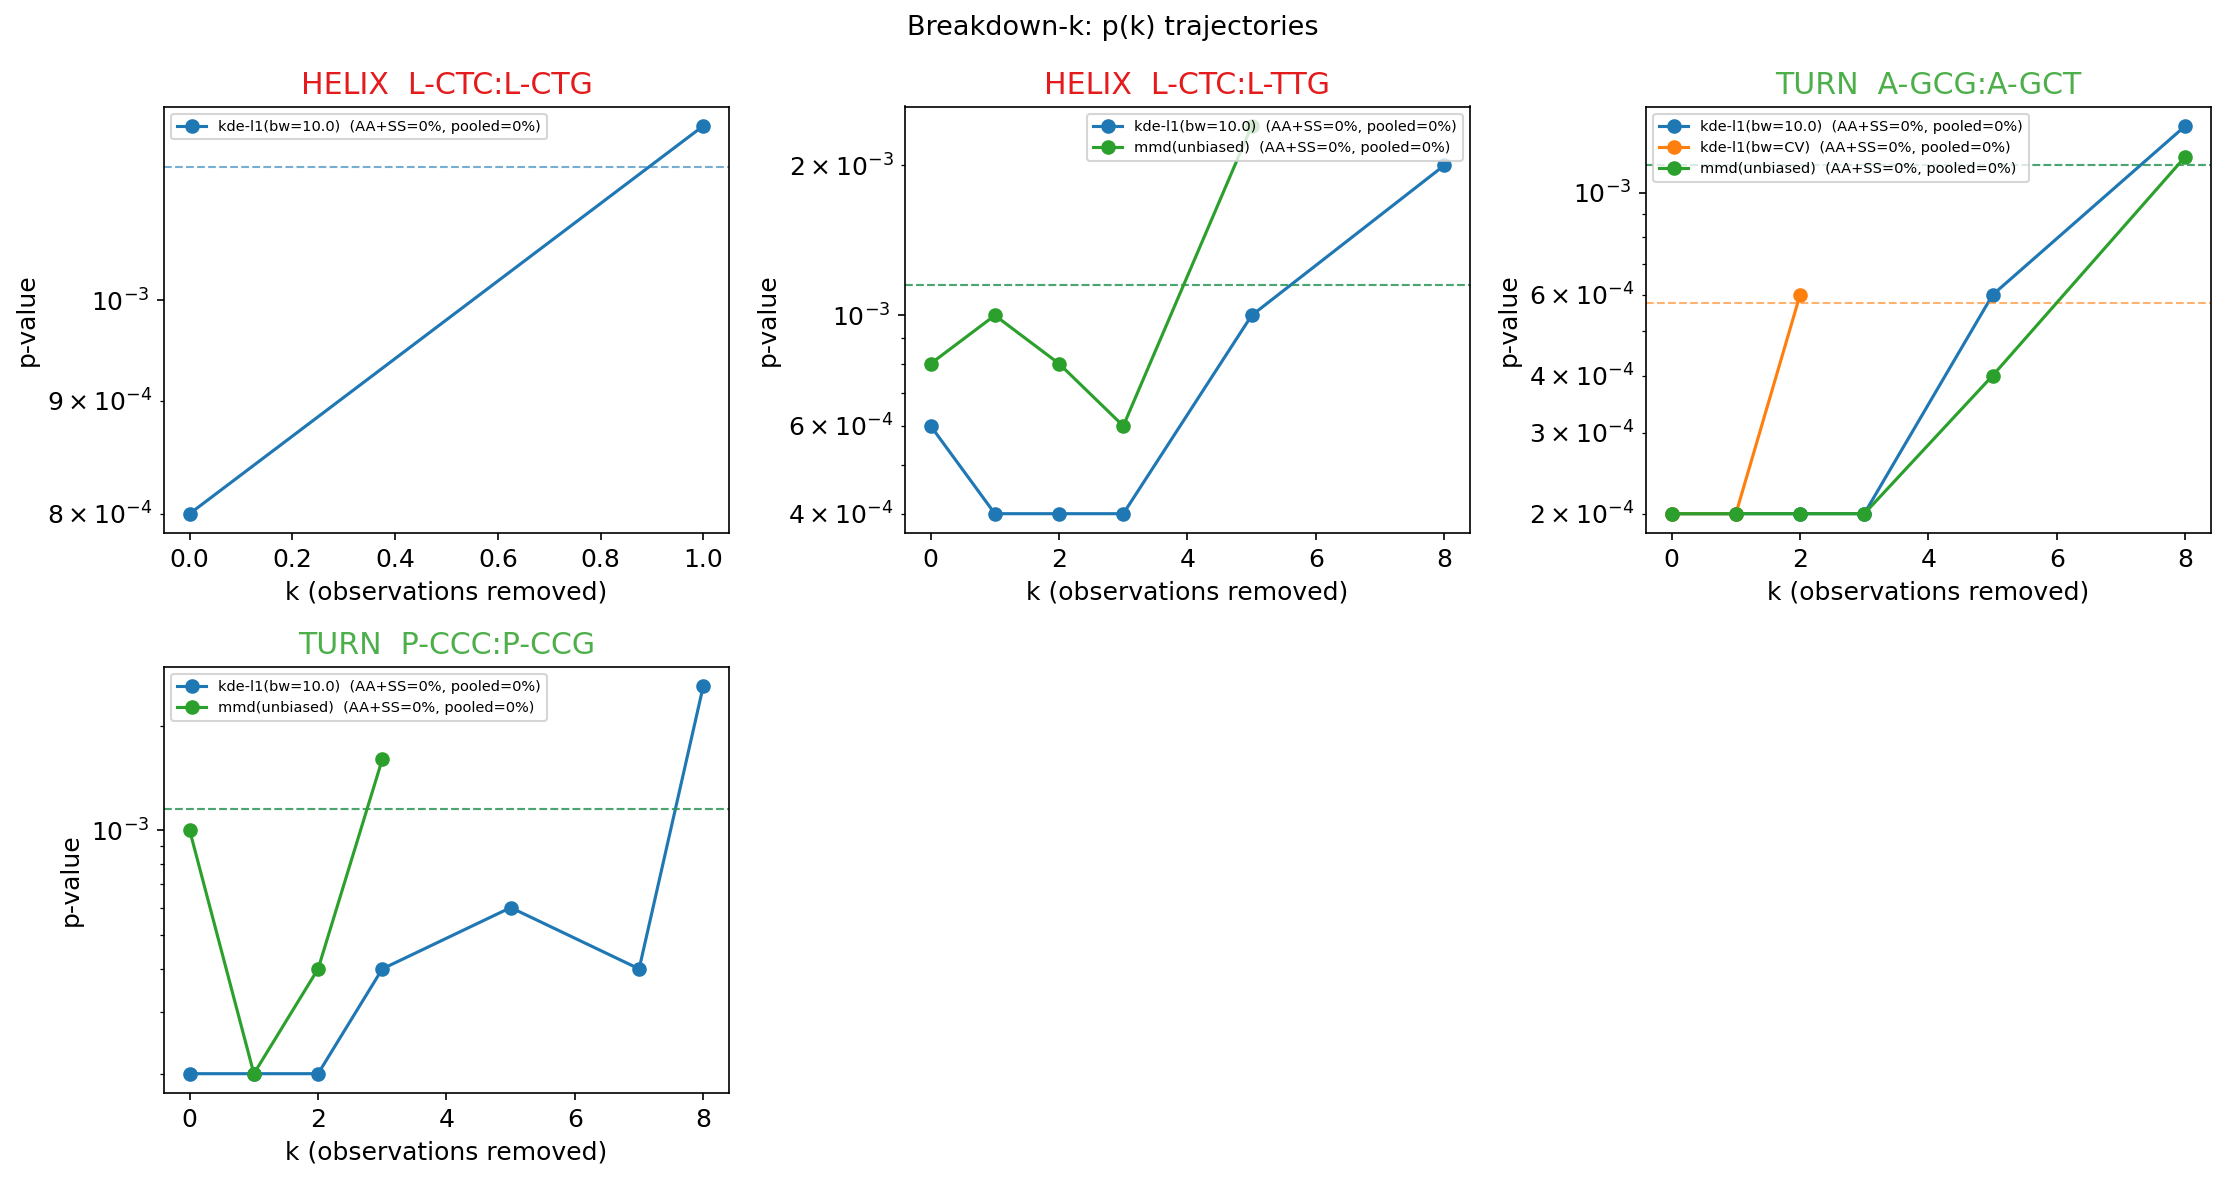

In [29]:
pairs_with_trajectories = sorted({(ss, pair) for (ss, pair, arm) in p_trajectories})

if not pairs_with_trajectories:
    print(
        "No breakdown-k trajectories recorded -- no arm found any candidate pair "
        "significant in this run (or only the cached torus arm did, which has no "
        "per-k trajectory)."
    )
else:
    arm_colors = dict(
        zip(BREAKDOWN_ARMS, sns.color_palette("tab10", n_colors=len(BREAKDOWN_ARMS)))
    )
    ncols = min(3, len(pairs_with_trajectories))
    nrows = int(np.ceil(len(pairs_with_trajectories) / ncols))

    with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False
        )
        axes = axes.flatten()

        for ax, (ss, pair) in zip(axes, pairs_with_trajectories):
            for arm in BREAKDOWN_ARMS:
                key = (ss, pair, arm)
                if key not in p_trajectories:
                    continue
                traj = pd.DataFrame(p_trajectories[key])
                color = arm_colors[arm]

                thresh = float(
                    real_rejections.loc[
                        (real_rejections["stat_test"] == arm)
                        & (real_rejections["SS"] == ss),
                        "bh_pvalue_threshold",
                    ].iloc[0]
                )
                row = df_breakdown_all[
                    (df_breakdown_all["SS"] == ss)
                    & (df_breakdown_all["pair"] == pair)
                    & (df_breakdown_all["statistic"] == arm)
                ].iloc[0]
                label = (
                    f"{arm}  (AA+SS={row['aass_frac_sig']:.0%}, "
                    f"pooled={row['pooled_frac_sig']:.0%})"
                )

                ax.plot(traj["k"], traj["p"], marker="o", color=color, label=label)
                ax.axhline(thresh, color=color, ls="--", lw=1, alpha=0.6)

            ax.set_yscale("log")
            ax.set_xlabel("k (observations removed)")
            ax.set_ylabel("p-value")
            ax.set_title(f"{ss}  {pair}", color=ss_colors.get(ss, "black"))
            ax.legend(fontsize=7)

        for ax in axes[len(pairs_with_trajectories) :]:
            ax.set_visible(False)

        fig.suptitle("Breakdown-k: p(k) trajectories", fontsize=13)
        plt.tight_layout()
        fig.savefig(OUT_DIR / "r1_breakdown_trajectories.pdf")
        plt.show()

### R2 -- sample-size bias

Spearman(min(n1, n2), ddist) for KDE-L1(bw=10) vs. unbiased MMD-squared, over **all** 87 x 4(SS)
real-data pairs (not just the 6 candidates) -- read directly off `df_all_pvals`, no new
computation. The methodological case for MMD as primary: historically, KDE-L1 shows a strong
negative bias (smaller groups -> larger apparent distance, rho ~ -0.64) while MMD-unbiased does
not (rho ~ +0.04).

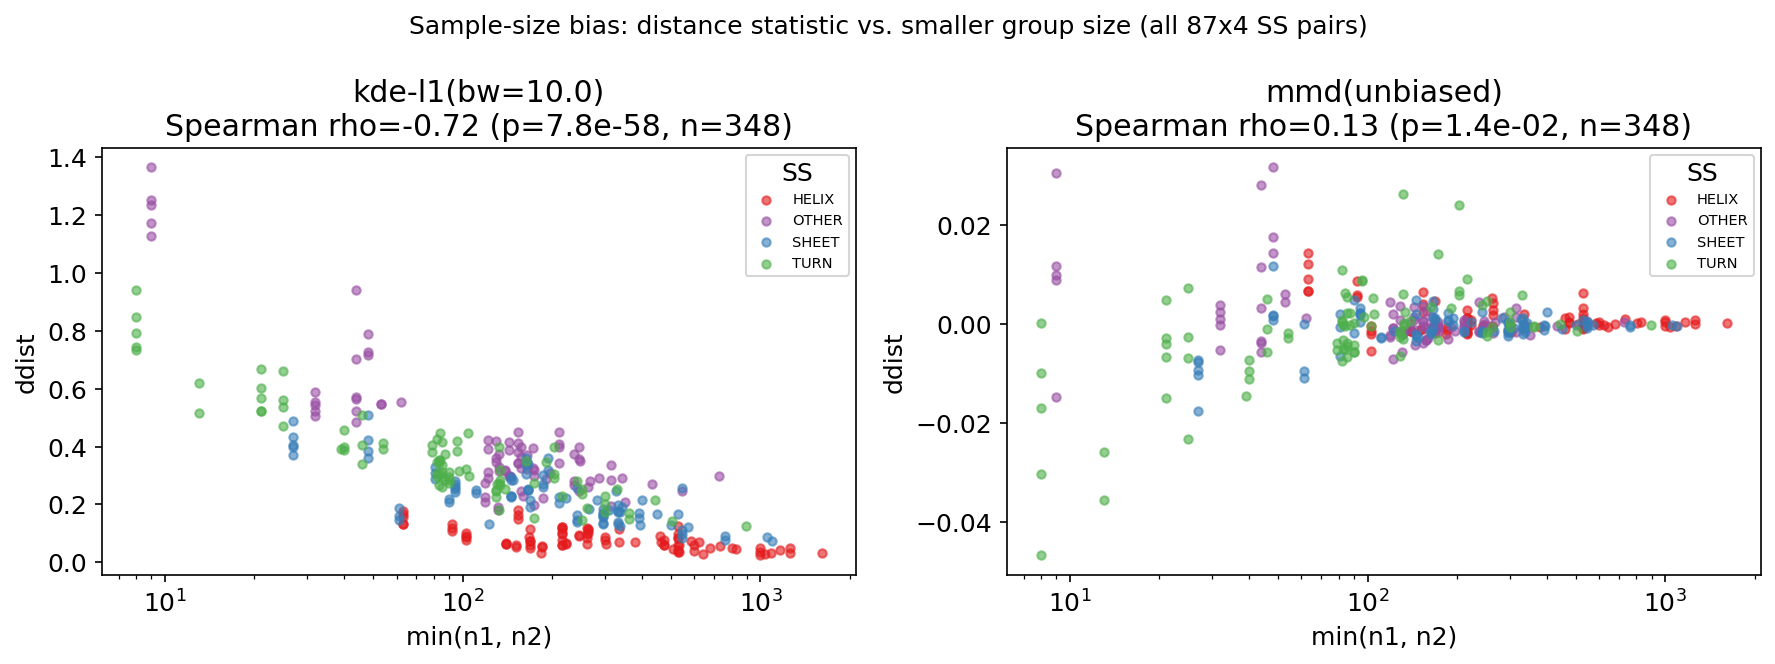

In [30]:
R2_STATS = ["kde-l1(bw=10.0)", "mmd(unbiased)"]

df_r2 = df_all_pvals[
    (df_all_pvals["codon_randomization"] == "none")
    & (df_all_pvals["stat_test"].isin(R2_STATS))
].copy()
df_r2["min_n"] = df_r2[["n1", "n2"]].min(axis=1)

with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
    fig, axes = plt.subplots(1, len(R2_STATS), figsize=(6 * len(R2_STATS), 4.5))
    for ax, stat in zip(axes, R2_STATS):
        sub = df_r2[df_r2["stat_test"] == stat]
        rho, spearman_p = spearmanr(sub["min_n"], sub["ddist"])
        for ss, ss_sub in sub.groupby("condition_group"):
            ax.scatter(
                ss_sub["min_n"],
                ss_sub["ddist"],
                s=16,
                alpha=0.6,
                color=ss_colors.get(ss, "0.4"),
                label=ss,
            )
        ax.set_xscale("log")
        ax.set_xlabel("min(n1, n2)")
        ax.set_ylabel("ddist")
        ax.set_title(
            f"{stat}\nSpearman rho={rho:.2f} (p={spearman_p:.1e}, n={len(sub)})"
        )
        ax.legend(fontsize=7, title="SS")

    fig.suptitle(
        "Sample-size bias: distance statistic vs. smaller group size (all 87x4 SS pairs)",
        fontsize=12,
    )
    plt.tight_layout()
    fig.savefig(OUT_DIR / "r2_sample_size_bias.pdf")
    plt.show()

### R3 -- breakdown-k heatmap

Heatmap view of the breakdown-k matrix above: color encodes robustness (breakdown-k count,
with a sentinel value above the observed maximum for "robust" pairs that never broke down);
cell text carries the same label as the table (`"n.s."` / `"robust"` / `"not computed"` /
integer k).

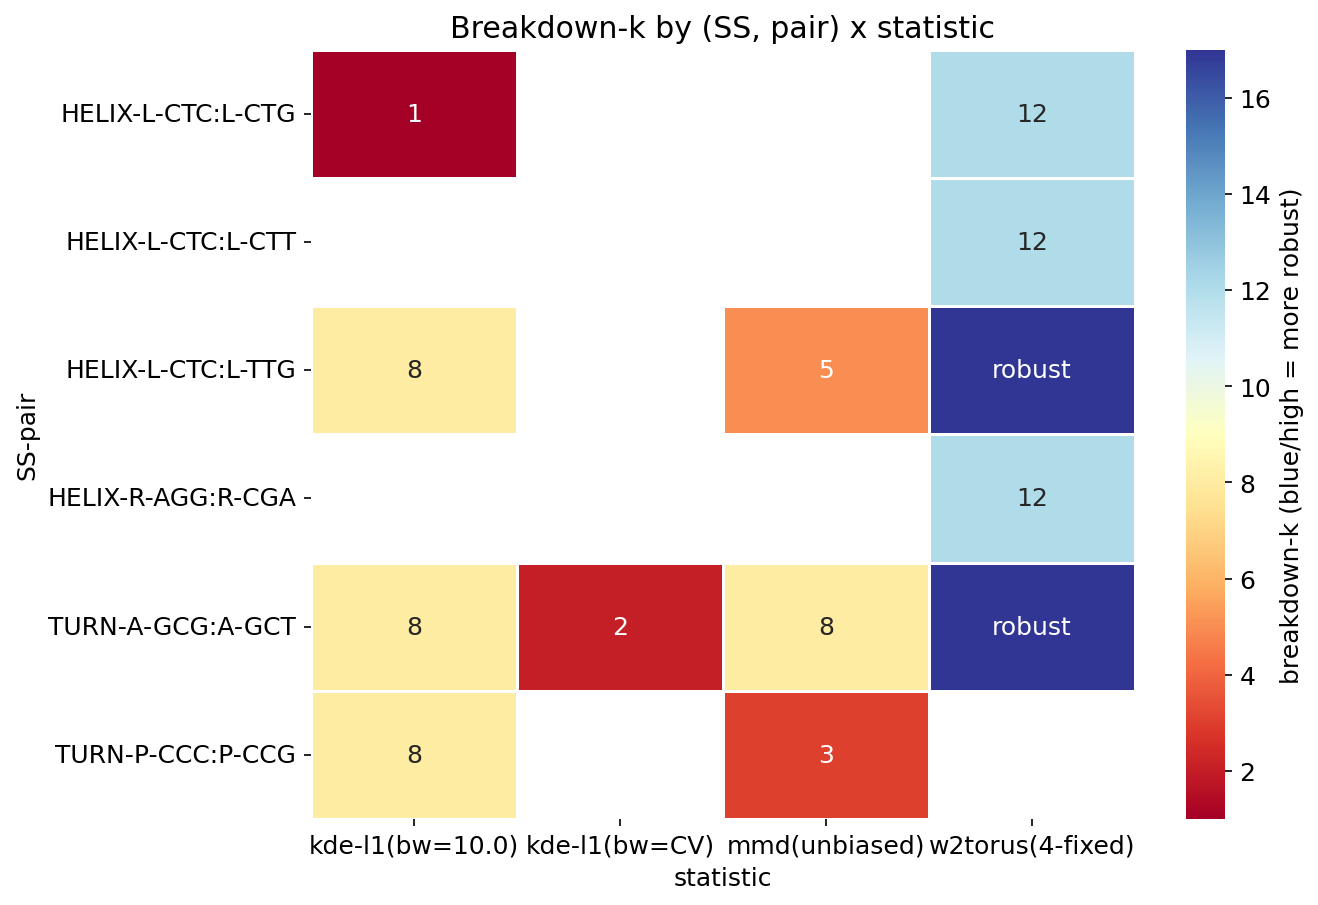

In [31]:
_max_bk = df_breakdown_all["breakdown_k"].max()
_robust_sentinel = (_max_bk if pd.notna(_max_bk) else 0) + 5

_is_sig = df_breakdown_all["significant"].eq(True)
df_breakdown_all["_heatmap_value"] = np.where(
    _is_sig, df_breakdown_all["breakdown_k"].fillna(_robust_sentinel), np.nan
)

mat_color = df_breakdown_all.pivot_table(
    index=["SS", "pair"], columns="statistic", values="_heatmap_value", aggfunc="first"
)
mat_label = df_breakdown_k_matrix.reindex_like(mat_color)

with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
    fig, ax = plt.subplots(
        figsize=(1.8 * mat_color.shape[1] + 2, 0.7 * mat_color.shape[0] + 2)
    )
    sns.heatmap(
        mat_color,
        annot=mat_label.values,
        fmt="",
        cmap="RdYlBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "breakdown-k (blue/high = more robust)"},
    )
    ax.set_title("Breakdown-k by (SS, pair) x statistic")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "r3_breakdown_k_heatmap.pdf")
    plt.show()

### R4 -- kill-set Ramachandran plot

One panel per SS class with kill-set points: background scatter of every point in that class
(from `dataset.csv`), kill-set points from `df_kill_sets` overlaid on top, colored by codon.
Shows whether adversarially-removed points sit in tight allowed-region clusters (as expected
if they're genuine outliers) rather than scattered broadly across the background.

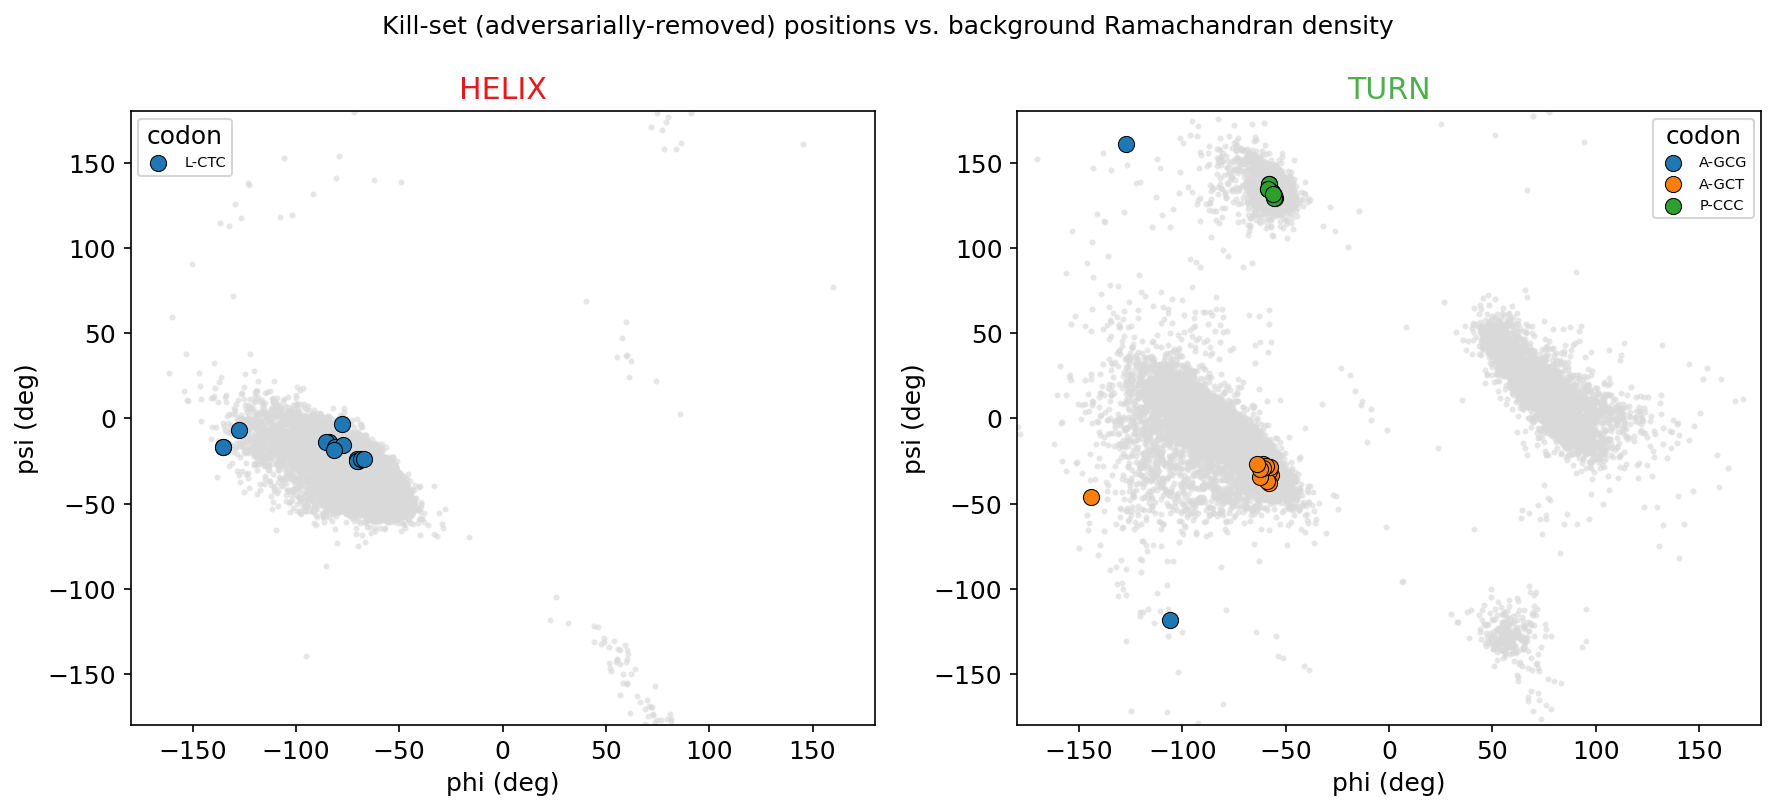

In [32]:
if not len(df_kill_sets):
    print("No kill-set points to plot (no arm had a finite breakdown-k).")
else:
    ss_classes_present = sorted(df_kill_sets["SS"].unique())

    with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
        fig, axes = plt.subplots(
            1,
            len(ss_classes_present),
            figsize=(6 * len(ss_classes_present), 5.5),
            squeeze=False,
        )
        axes = axes[0]

        for ax, ss in zip(axes, ss_classes_present):
            background = df_dataset[df_dataset["condition_group"] == ss]
            ax.scatter(
                background["phi"],
                background["psi"],
                s=4,
                color="0.85",
                alpha=0.5,
                rasterized=True,
            )

            sub = df_kill_sets[df_kill_sets["SS"] == ss]
            codons = sorted(sub["codon"].unique())
            codon_colors = dict(
                zip(codons, sns.color_palette("tab10", n_colors=len(codons)))
            )
            for codon in codons:
                csub = sub[sub["codon"] == codon]
                ax.scatter(
                    csub["phi_mean"],
                    csub["psi_mean"],
                    s=60,
                    color=codon_colors[codon],
                    edgecolor="black",
                    linewidth=0.5,
                    label=codon,
                    zorder=3,
                )

            ax.set_xlim(-180, 180)
            ax.set_ylim(-180, 180)
            ax.set_xlabel("phi (deg)")
            ax.set_ylabel("psi (deg)")
            ax.set_title(ss, color=ss_colors.get(ss, "black"))
            ax.legend(fontsize=7, title="codon")

        fig.suptitle(
            "Kill-set (adversarially-removed) positions vs. background Ramachandran density",
            fontsize=12,
        )
        plt.tight_layout()
        fig.savefig(OUT_DIR / "r4_kill_set_ramachandran.pdf")
        plt.show()